In [1]:
pip install rasterio opencv-python numpy matplotlib

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/30.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/30.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/30.9 MB ? eta -:--:--
    --------------------------------------- 0.5/30.9 MB 1.2 MB/s eta 0:00:26
   - -------------------------------------- 0.8/30.9 MB 1.2 MB/s eta 0:00:26
   - -------------------------------------- 1.0/30.9 MB 1.2 MB/s eta 0:00:25
   - -------------------------------------- 1.3/30.9 MB 1.2 MB/s eta 0:00:25
   -- ------------------------------------- 1.6/30.9 MB 1.2 MB/s eta 0:00:25
   -- ------------------------------------- 1.8/30.9 MB 1.2 MB/s eta 0:00:25
   -- ------------------------------------- 2.1/30.9 MB 1.2 MB/s eta 0:00:25
   --- ------------------------------------ 2.4/30.9 MB 1.2 MB/s eta 0:00:25
   --- ------------------------------------ 2.4/30.9 MB 1.2 MB/s eta 0:00:25
   --- ------------

Starting analysis...


C:\Users\piyus\AppData\Roaming\Python\Python314\site-packages\rasterio\__init__.py:379: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


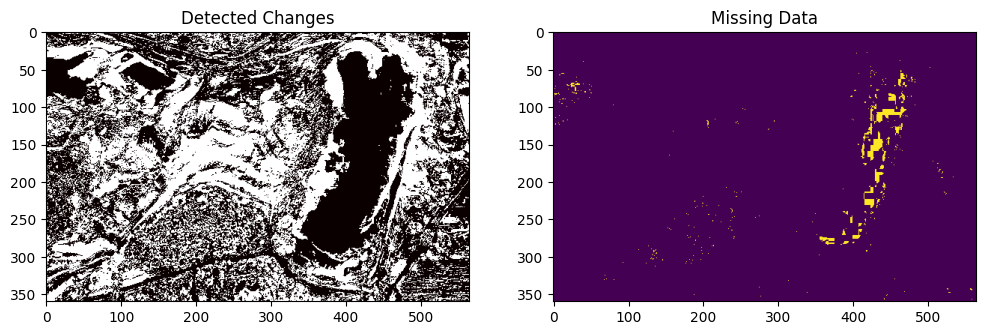

DONE! Found 93971 changed pixels.
Sample Coordinates: [{'lat': np.float64(0.5), 'lon': np.float64(0.5)}, {'lat': np.float64(0.5), 'lon': np.float64(1.5)}, {'lat': np.float64(0.5), 'lon': np.float64(2.5)}, {'lat': np.float64(0.5), 'lon': np.float64(11.5)}, {'lat': np.float64(0.5), 'lon': np.float64(15.5)}, {'lat': np.float64(0.5), 'lon': np.float64(21.5)}, {'lat': np.float64(0.5), 'lon': np.float64(22.5)}, {'lat': np.float64(0.5), 'lon': np.float64(23.5)}, {'lat': np.float64(0.5), 'lon': np.float64(32.5)}, {'lat': np.float64(0.5), 'lon': np.float64(33.5)}]


In [6]:
import rasterio
from rasterio.plot import show
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. FIXED PATHS (Using 'r' to avoid SyntaxWarning)
path_before = r"D:\eco hackathon\path1.jpg"
path_after = r"D:\eco hackathon\path2.jpg"

def analyze_satellite_imagery(path_before, path_after, threshold=40):
    # Use a try-except block to catch errors if files are missing
    try:
        with rasterio.open(path_before) as src1, rasterio.open(path_after) as src2:
            # Read image data
            img1 = src1.read(1).astype(np.float32)
            img2 = src2.read(1).astype(np.float32)
            
            # CRITICAL: If images are different sizes, resize img2 to match img1
            if img1.shape != img2.shape:
                img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

            transform = src1.transform
            crs = src1.crs

            # 2. Identify Missing Pixels
            missing_mask = (img1 == 0) | (img2 == 0)
            
            # 3. Change Detection
            diff = np.abs(img1 - img2)
            change_mask = np.where((diff > threshold) & (~missing_mask), 255, 0).astype(np.uint8)

            # 4. Extract Locations
            change_rows, change_cols = np.where(change_mask == 255)
            
            # Convert first 10 changes to Lat/Lon
            locations = []
            for r, c in zip(change_rows[:10], change_cols[:10]):
                lon, lat = rasterio.transform.xy(transform, r, c)
                locations.append({"lat": lat, "lon": lon})

            # 5. Visual Output
            plt.figure(figsize=(12, 4))
            plt.subplot(1, 2, 1); plt.title("Detected Changes"); plt.imshow(change_mask, cmap='hot')
            plt.subplot(1, 2, 2); plt.title("Missing Data"); plt.imshow(missing_mask, cmap='viridis')
            plt.show()

            return {
                "total_changes": len(change_rows),
                "gps_samples": locations,
                "crs": str(crs)
            }
    except Exception as e:
        return f"Error: {e}"

# --- THIS PART ACTUALLY RUNS THE CODE ---
print("Starting analysis...")
results = analyze_satellite_imagery(path_before, path_after)

if isinstance(results, dict):
    print(f"DONE! Found {results['total_changes']} changed pixels.")
    print("Sample Coordinates:", results['gps_samples'])
else:
    print(results)

In [ ]:
import rasterio
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Using raw strings to fix the path error
path_before = r"D:\eco hackathon\path1.jpg"
path_after = r"D:\eco hackathon\path2.jpg"

def visualize_missing_data(path_before, path_after, threshold=40):
    try:
        with rasterio.open(path_before) as src1, rasterio.open(path_after) as src2:
            img1 = src1.read(1).astype(np.float32)
            img2 = src2.read(1).astype(np.float32)
            
            # Match sizes if they differ
            if img1.shape != img2.shape:
                img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

            # 1. Create the Missing Mask (where pixels are 0 or very dark)
            # You can adjust 'img1 <= 5' if your "missing" data isn't exactly 0
            missing_mask = (img1 <= 0) | (img2 <= 0)

            # 2. Create the "Satellite View" of missing data
            # We take the original image and multiply it by the mask
            # This shows ONLY the pixels that were flagged as missing
            missing_data_visual = np.where(missing_mask, img1, 0)

            # 3. Visualization
            plt.figure(figsize=(20, 10))

            plt.subplot(1, 3, 1)
            plt.title("Full Satellite Image")
            plt.imshow(img1, cmap='gray')
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.title("Missing Data Mask (Binary)")
            plt.imshow(missing_mask, cmap='Purples')
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.title("Visual of Missing Pixels Only")
            plt.imshow(missing_data_visual, cmap='gray')
            plt.axis('off')

            plt.show()
            
            print(f"Missing Pixels Detected: {np.sum(missing_mask)}")
            
    except Exception as e:
        print(f"Error: {e}")

# Run the visualizer
visualize_missing_data(path_before, path_after)